In [3]:
# %pip install xgboost
# %pip install numpy
# %pip install scikit-learn
# %pip install pandas
# %pip install matplotlib

## Loading Packages

**numpy** is imported for working with arrays and integration with **pandas**, which is used for converting .csv data into dataframe objects. Data frame objects are used for data wrangling, feature engineering, and passing through models, which are carried in **xgboost**. The model of choice is a gradient boosted decision tree for classification. Any additional machine learning convinence tools used in training or validating will be included in **scikit-learn**. All tools are listed in **requirements.txt**.

In [4]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

## Loading Titanic Data, Data Wrangling, and Feature Engineering

In [5]:
df = pd.read_csv("train.csv")
df.shape

(891, 12)

Within the "training" data, there are 12 features included and 891 cases where each case represents a passenger on the Titanic, a preview of the first 5 instances of the dataframe:

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Here are the recorded features provided in the data:
1. PassengerId - a unique, in-order, whole number describing a passenger
2. Survived - the survival condition of the passenger (0 <- Did not survive, 1 <- Survived)
3. Pclass - the ticket class of the passenger ranging from 1 ~ 3
4. Name - last name, how the passenger is addressed (Mr, Mrs, Miss, etc.) and first name
5. Sex - the sex of the passenger (male/female)
6. Age - the age of the passenger
7. SibSp - the number of siblings or spouse that are onboard
8. Parch - the number of parents or children that are onboard
9. Ticket - the ticket number of the passenger
10. Fare - the fare the passenger paid to onboard (some passengers might have paid fares for multiple people while other might have his or her fare already paid)
11. Cabin - the cabin number of the cabin the passenger stayed
12. Embarked - the port that the passenger embarked at (C = Cherbourg, Q = Queenstown, S = Southampton)

From these observed features, there are a couple that are easy to rule out as irrelevant towards whether or not the passenger survives: **PassengerId** and **Ticket**, since they do not describe anything relating to the passenger's escaping situation nor how they were situationed on the Titanic. I would like to first explore **Name**, since multiple pieces of information can be extracted from it (Surname and title). First, I want to work on parsing **Name** into **Surname**, **Title**, and **RestOfName**. In addition, attempting to try to fix the issue of **Fare** not always being the fare that is paid by the individual, I will group people boarding in groups via ticket numbers and create a new feature **FarePerPerson**. Finally, **SibSp** and **Parch** are quite similar, thus I believe that they carry similar signals. I would like to combine the 2 via a new feature **FamilySize** accord to the following formula:

**FamilySize** = **SibSp** + **Parch** + 1

A few other features will also be created and tallied at the end.

In [7]:
df[["Surname", "Rest"]] = df["Name"].str.split(",", n = 1, expand = True)
df[["Title", "RestOfName"]] = df["Rest"].str.split(".", n = 1, expand = True)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
ticket_group_size = df.groupby("Ticket")["Ticket"].transform("count")
df["FarePerPerson"] = df["Fare"] / ticket_group_size
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Has_Cabin"] = df["Cabin"].notna().astype(int)
df["Age_missing"] = df["Age"].isna().astype(int)
df = df.drop(columns = ["PassengerId", "Ticket", "Name", "Rest"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Surname,Title,RestOfName,FamilySize,FarePerPerson,IsAlone,Has_Cabin,Age_missing
0,0,3,male,22.0,1,0,7.2500,NaN,S,Braund,Mr,Owen Harris,2,7.2500,0,0,0
1,1,1,female,38.0,1,0,71.2833,C85,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer),2,71.2833,0,1,0
2,1,3,female,26.0,0,0,7.9250,NaN,S,Heikkinen,Miss,Laina,1,7.9250,1,0,0
3,1,1,female,35.0,1,0,53.1000,C123,S,Futrelle,Mrs,Jacques Heath (Lily May Peel),2,26.5500,0,1,0
4,0,3,male,35.0,0,0,8.0500,NaN,S,Allen,Mr,William Henry,1,8.0500,1,0,0


As a good habit of exploratory data analysis, below is a viewing of the distribution of non-indicator random variables like **Age**, **Fare**, and **FarePerPerson**. From the histograms, **Fare** and **FarePerPerson** are rightskewed. Although gradient boosted trees don't strictly need this, other potential statistics methods assumes normality or symmetry, so usually taking the nature logs of these values can improve this issue.

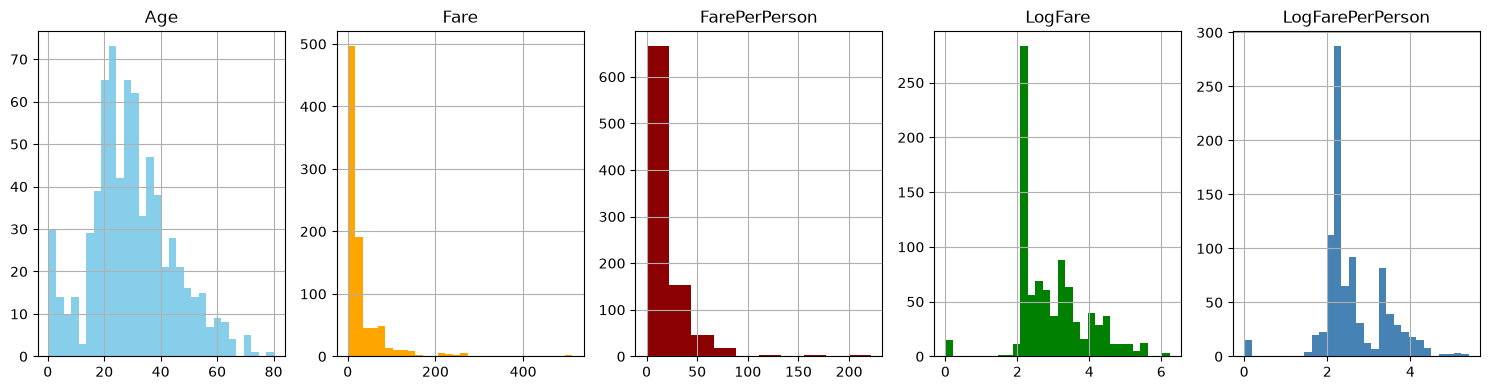

In [8]:
fig, axes = plt.subplots(1, 5, figsize = (15, 4))
df["Age"].hist(bins = 30, color = "skyblue", ax = axes[0])
axes[0].set_title("Age")
df["Fare"].hist(bins = 30, color = "orange", ax = axes[1])
axes[1].set_title("Fare")
df["FarePerPerson"].hist(bins = 10, color = "darkred", ax = axes[2])
axes[2].set_title("FarePerPerson")

# Taking the log of Fare and FarePerPerson
df["LogFare"] = np.log1p(df["Fare"])
df["LogFarePerPerson"] = np.log1p(df["FarePerPerson"])

df["LogFare"].hist(bins = 30, color = "green", ax = axes[3])
axes[3].set_title("LogFare")
df["LogFarePerPerson"].hist(bins = 30, color = "steelblue", ax = axes[4])
axes[4].set_title("LogFarePerPerson")

plt.tight_layout()
plt.show()

In [9]:
# Getting rid of redunant or intermediate features and correct typing
for col in ["Sex", "Embarked", "Title", "Cabin"]:
    df[col] = df[col].astype("category")
df = df.drop(columns = ["Fare", "FarePerPerson", "RestOfName", "Surname"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Cabin,Embarked,Title,FamilySize,IsAlone,Has_Cabin,Age_missing,LogFare,LogFarePerPerson
0,0,3,male,22.0,1,0,NaN,S,Mr,2,0,0,0,2.110213,2.110213
1,1,1,female,38.0,1,0,C85,C,Mrs,2,0,1,0,4.280593,4.280593
2,1,3,female,26.0,0,0,NaN,S,Miss,1,1,0,0,2.188856,2.188856
3,1,1,female,35.0,1,0,C123,S,Mrs,2,0,1,0,3.990834,3.316003
4,0,3,male,35.0,0,0,NaN,S,Mr,1,1,0,0,2.202765,2.202765


Now, a retally of all the features that will be inculded for the model:
1. Pclass
2. Sex
3. Age
4. SibSp
5. Parch
6. Embarked
7. Title
8. FamilySize
9. IsAlone
10. Has_Cabin
11. Age_missing
12. LogFare
13. LogFarePerPerson

## Gradient Boosted Tree
To better fine tune the framework, a simple discrete region of regularization constants are selected and choose to optimize accuracy over. Best regularization parameters are then selected in a cross-validation process. Other model parameter that I am unsure of Estimation runtime: 3 minutes.

In [10]:
y = df["Survived"]
X = df.drop(columns = ["Survived"])

# Reasonable region to optimize regularization constants over
param_grid = {
    "reg_lambda": np.arange(0, 10, 1).tolist(),
    "reg_alpha": np.arange(0, 5, 0.5).tolist(),
    "gamma": np.arange(0, 10, 1).tolist()
}

def optim_regularization(max_depth, param_grid):
    # Building the tree
    base_model = xgb.XGBClassifier(
        n_estimators = 100,
        max_depth = max_depth,
        learning_rate = 0.1,
        subsample = 0.8,
        colsample_bytree = 0.8,
        eval_metric = "logloss",
        random_state = 42,
        enable_categorical = True
    )

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

    grid_search = GridSearchCV(
        base_model,
        param_grid,
        scoring = "accuracy",
        cv = cv,
        n_jobs = -1
    )

    grid_search.fit(X, y)
    results = pd.DataFrame(grid_search.cv_results_)

    return grid_search, results

# Running different max depth sizes
optims = {depth: optim_regularization(depth, param_grid) for depth in [3, 4, 5]}
models = []
for depth, optim in optims.items():
    best_params = optim[0].best_params_
    gamma_optim = best_params["gamma"]
    alpha_optim = best_params["reg_alpha"]
    lambda_optim = best_params["reg_lambda"]

    models.append(
        xgb.XGBClassifier(
            max_depth = depth,
            n_estimators = 100,
            learning_rate = 0.1,
            subsample = 0.8, 
            colsample_bytree = 0.8,
            gamma = gamma_optim, 
            reg_alpha = alpha_optim, 
            reg_lambda = lambda_optim,
            eval_metric="logloss", 
            random_state = 42,
            enable_categorical = True
        )
    )

for seed in range(21):
    cv_seed = StratifiedKFold(n_splits = 5, shuffle = True, random_state = seed)
    s3 = cross_val_score(models[0], X, y, cv = cv_seed, scoring = "accuracy").mean()
    s4 = cross_val_score(models[1], X, y, cv = cv_seed, scoring = "accuracy").mean()
    s5 = cross_val_score(models[2], X, y, cv = cv_seed, scoring = "accuracy").mean()
    print(f"seed = {seed}: depth3 = {s3:.4f}, depth4 = {s4:.4f}, depth5 = {s5:.4f}")

seed = 0: depth3 = 0.8384, depth4 = 0.8294, depth5 = 0.8283
seed = 1: depth3 = 0.8384, depth4 = 0.8272, depth5 = 0.8362
seed = 2: depth3 = 0.8473, depth4 = 0.8339, depth5 = 0.8429
seed = 3: depth3 = 0.8429, depth4 = 0.8316, depth5 = 0.8451
seed = 4: depth3 = 0.8418, depth4 = 0.8362, depth5 = 0.8395
seed = 5: depth3 = 0.8362, depth4 = 0.8328, depth5 = 0.8373
seed = 6: depth3 = 0.8317, depth4 = 0.8261, depth5 = 0.8384
seed = 7: depth3 = 0.8372, depth4 = 0.8384, depth5 = 0.8384
seed = 8: depth3 = 0.8250, depth4 = 0.8351, depth5 = 0.8396
seed = 9: depth3 = 0.8328, depth4 = 0.8361, depth5 = 0.8384
seed = 10: depth3 = 0.8327, depth4 = 0.8260, depth5 = 0.8350
seed = 11: depth3 = 0.8384, depth4 = 0.8339, depth5 = 0.8395
seed = 12: depth3 = 0.8428, depth4 = 0.8384, depth5 = 0.8361
seed = 13: depth3 = 0.8306, depth4 = 0.8373, depth5 = 0.8407
seed = 14: depth3 = 0.8362, depth4 = 0.8317, depth5 = 0.8305
seed = 15: depth3 = 0.8373, depth4 = 0.8316, depth5 = 0.8361
seed = 16: depth3 = 0.8272, depth4

From these observations, there is not a very substantial difference between the 3, although a max depth of 3 or 4 is probably perfered over 5. For now, we will continue with a max depth of 3 as it slightly outperformed a max depth of 4. Below is a heat map of optimizing regularization parameters with a max depth of 3:

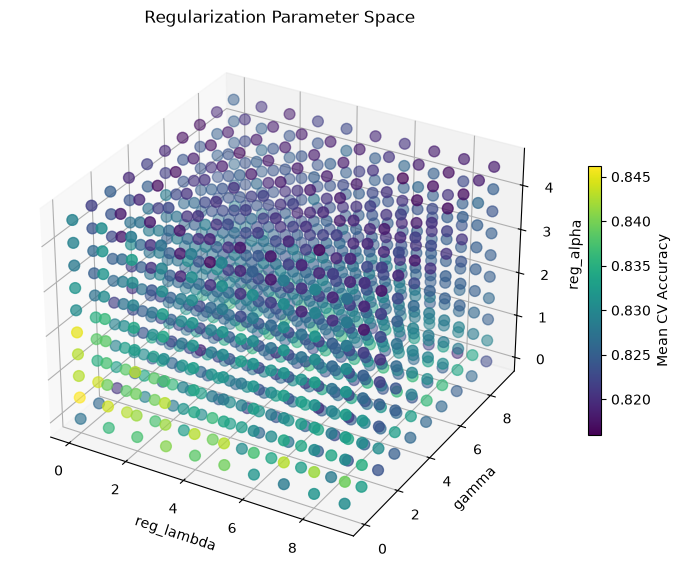

best regularization parameter: {'gamma': 0, 'reg_alpha': 0.5, 'reg_lambda': 0}
Accuracy: 0.8462306195467957


In [11]:
results = optims[3][1]
fig = plt.figure(figsize = (10, 7))
ax = fig.add_subplot(111, projection = "3d")

scatter = ax.scatter( 
    results["param_reg_lambda"].astype(float),
    results["param_gamma"].astype(float),
    results["param_reg_alpha"].astype(float), # type: ignore[arg-type]
    c = results["mean_test_score"],
    cmap = "viridis",
    s = 60
)

ax.set_xlabel("reg_lambda")
ax.set_ylabel("gamma")
ax.set_zlabel("reg_alpha")
ax.set_title("Regularization Parameter Space")
fig.colorbar(scatter, shrink = 0.5, label = "Mean CV Accuracy")
plt.show()

print(f"best regularization parameter: {optims[3][0].best_params_}\nAccuracy: {optims[3][0].best_score_}")

Thus, the final model will be using a depth of 3 and the respective optimal regularization parameters.

In [12]:
final_model = models[0]
final_model.fit(X, y)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Predictions
The same process that the training data went through will be applied with the new data, and the output will consistent of a vector with each value taking the value either 0 or 1 in the format of a .csv.

In [ ]:
test_raw = pd.read_csv("test.csv")
passenger_ids = test_raw["PassengerId"]

df1 = test_raw.copy()

df1[["Surname", "Rest"]] = df1["Name"].str.split(",", n = 1, expand = True)
df1[["Title", "RestOfName"]] = df1["Rest"].str.split(".", n = 1, expand = True)
df1["FamilySize"] = df1["SibSp"] + df1["Parch"] + 1

ticket_group_size = df1.groupby("Ticket")["Ticket"].transform("count")
df1["FarePerPerson"] = df1["Fare"] / ticket_group_size
df1["IsAlone"] = (df1["FamilySize"] == 1).astype(int)
df1["Has_Cabin"] = df1["Cabin"].notna().astype(int)
df1["Age_missing"] = df1["Age"].isna().astype(int)

df1 = df1.drop(columns = ["PassengerId", "Ticket", "Name", "Rest"])

# Impute the one missing Fare value before logging (test.csv has exactly 1 NaN Fare)
df1["Fare"] = df1["Fare"].fillna(df1["Fare"].median())
df1["FarePerPerson"] = df1["FarePerPerson"].fillna(df1["FarePerPerson"].median())

df1["LogFare"] = np.log1p(df1["Fare"])
df1["LogFarePerPerson"] = np.log1p(df1["FarePerPerson"])

for col in ["Sex", "Embarked", "Title", "Cabin"]:
    df1[col] = df1[col].astype(object)
    df1[col] = df1[col].where(df1[col].isin(X[col].cat.categories))
    df1[col] = pd.Categorical(df1[col], categories=X[col].cat.categories)

df1 = df1.drop(columns = ["Fare", "FarePerPerson", "RestOfName", "Surname"])


df1 = df1[X.columns]
preds = final_model.predict(df1)

submission = pd.DataFrame({"PassengerId": passenger_ids, "Survived": preds})
# submission.to_csv("submission.csv", index = False)
submission.head(20)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0
